<a href="https://colab.research.google.com/github/LilRed92/ai201-lab3-podclassifier-starter/blob/main/s2b_ai201_week3_colab_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 201 — Week 3 Demo: Spotify Artist Bio Generator

**For instructors.** Run this notebook in Google Colab with a GPU runtime.

**Runtime → Change runtime type → T4 GPU** (free tier is fine)

---

We're fine-tuning a small language model to write Spotify-style artist bios — the evocative, music-journalist-at-2am descriptions that capture an artist's vibe rather than listing their discography.

The base model produces generic summaries. After fine-tuning on ~65 examples, it starts hitting the specific tone.

**What we're covering:**
- What training data for fine-tuning actually looks like
- How to configure and run a LoRA fine-tuning job
- How to read a loss curve
- Before/after evaluation

**What you write live:**
1. Two or three training examples (to show what the data format looks like and what makes a good example)
2. A `compare()` function that runs a prompt through both models side by side

**Estimated training time:** ~6–10 minutes on a T4 GPU

---
**Before class:** Run cells 1–3 (install + load model) before students arrive. The model download takes a few minutes.

In [ ]:
# Cell 1 — Install dependencies (run before class, takes ~3 min)
# Unsloth makes LoRA fine-tuning on Colab's T4 GPU fast and accessible.
!pip install unsloth --quiet
!pip install --no-deps trl peft accelerate bitsandbytes --quiet
!pip install datasets matplotlib --quiet
print('Installation complete.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 979.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 689.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Cell 2 — Imports + GPU check (run before class)
import torch
import json
import matplotlib.pyplot as plt
from datasets import Dataset
from unsloth import FastLanguageModel, is_bfloat16_supported
from unsloth.chat_templates import get_chat_template
from trl import SFTTrainer
from transformers import TrainingArguments

# Confirm GPU is available
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu} ({mem:.1f} GB VRAM)')
else:
    print('WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU: Tesla T4 (15.6 GB VRAM)


In [ ]:
# Cell 3 — Load the base model (run before class, takes ~2 min)
#
# We're using Llama 3.2 3B Instruct, loaded in 4-bit quantization.
# 4-bit quantization reduces memory usage enough to fit on Colab's free T4.
# LoRA lets us fine-tune a small fraction of the model's weights (~1-2%)
# rather than all of them — making training fast and cheap.

MODEL_NAME = 'unsloth/Llama-3.2-3B-Instruct'
MAX_SEQ_LENGTH = 512

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,           # auto-detect best dtype for this GPU
    load_in_4bit=True,    # 4-bit quantization for memory efficiency
)
tokenizer = get_chat_template(tokenizer, chat_template='llama-3')

print(f'Base model loaded: {MODEL_NAME}')
print(f'Parameters: {sum(p.numel() for p in base_model.parameters()) / 1e9:.1f}B')

==((====))==  Unsloth 2026.6.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Base model loaded: unsloth/Llama-3.2-3B-Instruct
Parameters: 1.8B


---
## Part 1: What the Base Model Does

Before we fine-tune anything, let's see what the model produces when we ask it to write a Spotify bio. This is our baseline — what we're trying to improve.

In [ ]:
# Cell 4 — Inference helper (used for both base and fine-tuned comparisons)

def generate(model, prompt: str, max_new_tokens: int = 150) -> str:
    """Run a prompt through the model and return the response."""
    FastLanguageModel.for_inference(model)
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors='pt'
    ).to('cuda')
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.8,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True).strip()


def bio_prompt(artist: str, genre: str, descriptors: str) -> str:
    """Format the standard bio request prompt."""
    return (
        f'Write a Spotify artist bio for {artist}. '
        f'Genre: {genre}. '
        f'Known for: {descriptors}. '
        f'Keep it to 2–3 evocative sentences. No bullet points, no facts, no discography. '
        f'Write like a music journalist who stayed up too late.'
    )

print('Helper functions defined.')

Helper functions defined.


In [ ]:
# ── FEW-SHOT BRIDGE — run before Demo Moment 1 ─────────────────────────────
# Before we fine-tune, show students the fastest alternative: put examples
# directly in the prompt (few-shot learning) and let the model infer the style.
#
# This takes zero GPU time and no training data — just a well-crafted prompt.
# Run it, show the output, then ask: "Is this close enough? When would it not be?"
#
# Bridge line: "Few-shot learning can get you partway there. But if the style is
# hard to describe in words and easy to show in examples — and you need it at scale
# without pasting this prompt into every single call — that's when you fine-tune."
# ─────────────────────────────────────────────────────────────────────────────

FEW_SHOT_PROMPT = """You write Spotify-style artist bios. Here are examples of the format:

Artist: SZA | Genre: R&B
Bio: SZA makes R&B that sounds like 3am and feels like a revelation. Her writing is unflinching — love, self-doubt, desire, and healing rendered in the same breath.

Artist: Tyler, the Creator | Genre: rap / neo-soul
Bio: Tyler doesn't make albums — he makes worlds. Each project is a controlled demolition of whatever he built before, rebuilt in a different key.

Artist: Phoebe Bridgers | Genre: indie folk
Bio: Phoebe Bridgers writes songs that feel like something you already knew but couldn't say. Quiet arrangements, devastating specificity.

Now write a bio for: Frank Ocean | Genre: R&B / neo-soul
Bio:"""

print('=== FEW-SHOT OUTPUT (base model, no fine-tuning) ===')
few_shot_output = generate(base_model, FEW_SHOT_PROMPT, max_new_tokens=120)
print(few_shot_output)
print()
print('--- Ask students: "Is this a Spotify bio? What would break this approach at scale?" ---')

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


=== FEW-SHOT OUTPUT (base model, no fine-tuning) ===


Both `max_new_tokens` (=120) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

Frank Ocean | Genre: R&B / neo-soul
Bio: Frank Ocean is a myth he's invented for himself, a persona born from the space between vulnerability and invincibility. His music is a cartography of the in-between, where love, desire, and identity blur and intersect. With lyrics that are both intensely personal and universally relatable, Ocean has become a touchstone for a generation seeking authenticity in a hyper-curated world.

--- Ask students: "Is this a Spotify bio? What would break this approach at scale?" ---


In [ ]:
# ── DEMO MOMENT 1 ──────────────────────────────────────────────────────────
# Show what the base model produces. It will be generic, factual, Wikipedia-ish.
# Ask students: "What's wrong with this as a Spotify bio?"
# Then: "What would it take to fix this with a system prompt instead of fine-tuning?"
# ───────────────────────────────────────────────────────────────────────────

SAMPLE_PROMPTS = [
    bio_prompt('Frank Ocean', 'R&B / neo-soul', 'introspective lyrics, rare releases, emotional depth'),
    bio_prompt('Mitski', 'indie rock', 'longing, intensity, live performances, literary lyrics'),
    bio_prompt('Tyler, the Creator', 'rap / neo-soul', 'genre-blending, visual art, personal growth'),
]

print('BASE MODEL OUTPUT (before fine-tuning)\n' + '='*60)
for prompt in SAMPLE_PROMPTS:
    artist = prompt.split('for ')[1].split('.')[0]
    print(f'\n[{artist}]')
    print(generate(base_model, prompt))
    print()

Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE MODEL OUTPUT (before fine-tuning)

[Frank Ocean]


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Frank Ocean is a sonic apparition, conjuring the ephemeral moments of love, longing, and existential dread that haunt us all. His voice is a vulnerable, haunted whisper that navigates the labyrinthine corridors of the human heart, where the past and present converge in a maelstrom of feeling. In his music, the boundaries between the personal and the universal dissolve, leaving only the eerie, beautiful ache of being alive.


[Mitski]


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Mitski's music is a slow-burning, elegiac requiem for the human condition, its jagged edges and falsetto wails conjuring the ghosts of youthful longing and existential despair. Like a novelist of the soundscapes, she crafts narratives that are at once deeply personal and universally relatable, her songs a mesmerizing fusion of introspection and catharsis. Live, she's a force of nature, a whirlwind of raw emotion and precision-crafted performance that can leave even the most hardened skeptic breathless.


[Tyler, the Creator]
Tyler, the Creator is a restless genius, forever probing the boundaries between the sonic and the visual, where the jazz-infused beats of his youth coexist with the avant-garde sensibilities of a grown man. His music is a deeply personal exploration of identity, community, and the search for meaning, all filtered through a lens of surreal humor and unflinching introspection. In the midst of a world that often seems too loud and too proud, Tyler's art is a quiet reb

---
## Part 2: Build the Training Data

Fine-tuning is only as good as the training data. Each example teaches the model one instance of: *this input → this output*.

For this task, every example is a structured prompt paired with a Spotify-style bio. The model will learn the style by seeing ~65 examples of it — not by being told what style means.

**✍️ LIVE CODE — write 2–3 training examples together:**

In [ ]:
# ── INSTRUCTOR: Write this live. ────────────────────────────────────────────
#
# Write 2–3 training examples before showing the full dataset.
# Each example is an (instruction, output) pair:
#   - instruction: the bio_prompt() format the model will see at inference time
#   - output: a 2–3 sentence evocative bio (NOT a Wikipedia summary)
#
# Ask students before writing:
#   "What makes a Spotify bio different from a Wikipedia summary?"
#   Guide toward: sensory language, emotional register, no facts/dates/awards
#
# After writing each one, ask: "Is this specific enough to teach a style?"
# The more specific and consistent the outputs, the faster the model learns.
#
# Key talking point:
#   "We're not telling the model what 'evocative' means.
#    We're showing it 65 examples of what we consider evocative.
#    The model learns the pattern from the data, not from the instruction."
# ────────────────────────────────────────────────────────────────────────────

live_examples = [
    {
        "instruction": bio_prompt("Phoebe Bridgers", "indie folk", "death, distance, quiet devastation"),
        "output": "Phoebe Bridgers writes about death and distance with the tone of someone texting from the backseat of a car. Everything is very casual and very devastating. Her songs arrive quietly and don't leave."
    },
    {
        "instruction": bio_prompt("SZA", "R&B", "vulnerability, self-doubt, searching"),
        "output": "SZA writes about wanting things you're not supposed to want, with the kind of casual honesty that makes everything around her feel like a lie. Her voice sounds like a question you keep asking yourself at 3am."
    },
    {
        "instruction": bio_prompt("James Blake", "electronic / soul", "minimalism, heartbreak, processed vocals"),
        "output": "James Blake makes music for the exact moment between sleeping and waking, when things almost make sense. His voice sounds like it learned how to hurt slowly."
    },
    {
        "instruction": bio_prompt("J Cole", "hip hop / rap", "poetic, energetic, slow"),
        "output": "J Cole writes songs about his life and societal issues. His songs sound smooth and groovy and fit a wide range of tastes."
    }
]

print(f'{len(live_examples)} live examples written.')
for ex in live_examples:
    artist = ex['instruction'].split('for ')[1].split('.')[0]
    print(f'  [{artist}]: "{ex["output"][:60]}..."')

4 live examples written.
  [Phoebe Bridgers]: "Phoebe Bridgers writes about death and distance with the ton..."
  [SZA]: "SZA writes about wanting things you're not supposed to want,..."
  [James Blake]: "James Blake makes music for the exact moment between sleepin..."
  [J Cole]: "J Cole writes songs about his life and societal issues. His ..."


In [ ]:
# Cell 7 — Full training dataset (pre-built — 65 examples across genres)
# The live examples above are included at the end.

TRAINING_DATA = [
    # ── R&B / Soul / Neo-Soul ──────────────────────────────────────────────
    {
        "instruction": bio_prompt("Frank Ocean", "R&B / neo-soul", "introspective lyrics, rare releases, emotional depth"),
        "output": "Frank Ocean moves through time like water through sand — slow, total, irreversible. His music asks what happens when you finally say the thing you've spent years circling around."
    },
    {
        "instruction": bio_prompt("Solange", "R&B / art pop", "Blackness, architecture of feeling, orchestral production"),
        "output": "Solange builds architecture out of feelings most people only pass through. Her records are rooms you can actually live in."
    },
    {
        "instruction": bio_prompt("Blood Orange", "R&B / indie soul", "wistfulness, walking home alone, lush production"),
        "output": "Dev Hynes makes music for the specific feeling of walking home alone after something good happened. Wistful, immaculate, slightly untethered."
    },
    {
        "instruction": bio_prompt("Daniel Caesar", "R&B", "voice as apology, devotional love songs, guitar"),
        "output": "Daniel Caesar's voice sounds like an apology and a confession happening at the same time. He sings about love like someone who has read every book about it and still can't figure it out."
    },
    {
        "instruction": bio_prompt("Sampha", "soul / electronic", "piano, grief, the space between feelings"),
        "output": "Sampha makes music from the space between a feeling and the word for it. His piano sounds like something remembered rather than played."
    },
    {
        "instruction": bio_prompt("H.E.R.", "R&B", "guitar, anonymity, unfinished emotional sentences"),
        "output": "H.E.R. plays guitar like she's working something out in real time. Her music lives in the pause before you say something you can't take back."
    },
    {
        "instruction": bio_prompt("D'Angelo", "neo-soul / funk", "groove, restraint, the space between notes"),
        "output": "D'Angelo made two albums and changed what soul music is allowed to be. The spaces between the notes are where everything happens."
    },
    {
        "instruction": bio_prompt("Erykah Badu", "neo-soul / spiritual", "alternate dimension, ceremony, prescient energy"),
        "output": "Erykah Badu has been living in a parallel dimension since 1997, reporting back periodically with evidence. Her music sounds like it arrived before it was written."
    },
    {
        "instruction": bio_prompt("Moses Sumney", "art pop / experimental R&B", "aloneness, falsetto, terror of being known"),
        "output": "Moses Sumney makes music about the terror of being known. His falsetto sounds like it's reaching for something that keeps moving."
    },
    {
        "instruction": bio_prompt("Syd", "R&B", "cool warmth, effortless production, Sunday ease"),
        "output": "Syd makes R&B that's as cool as it is warm — effortless in a way that's clearly thought through. Her music sounds like a Sunday afternoon in a place you love."
    },
    {
        "instruction": bio_prompt("Janelle Monáe", "funk / pop / afrofuturism", "political, danceable, alter ego"),
        "output": "Janelle Monáe has been playing a character who is more herself than she lets on. Her music is political and danceable in equal measure, and the dance floor is always the point."
    },
    # ── Rap / Hip-Hop ──────────────────────────────────────────────────────
    {
        "instruction": bio_prompt("Kendrick Lamar", "rap", "precision, concept albums, accountability"),
        "output": "Kendrick Lamar treats an album like a question he's been afraid to answer. His rap is precise the way surgery is precise — he cuts exactly where it matters."
    },
    {
        "instruction": bio_prompt("Tyler, the Creator", "rap / neo-soul", "chaos into genre, outgrowing yourself, visual art"),
        "output": "Tyler, the Creator made chaos into a genre and then outgrew it. Every album sounds like someone who learned something uncomfortable and decided to tell you about it anyway."
    },
    {
        "instruction": bio_prompt("Earl Sweatshirt", "rap", "looking without wanting to find, hazy production"),
        "output": "Earl Sweatshirt raps like he's looking for something and not sure he wants to find it. His verses feel like dreams you can almost remember."
    },
    {
        "instruction": bio_prompt("Noname", "conscious rap / jazz rap", "warmth, precision, writing about you specifically"),
        "output": "Noname raps like she's reading from a book she wrote about you specifically. Warm, precise, and significantly more unsettling than it first appears."
    },
    {
        "instruction": bio_prompt("Vince Staples", "rap", "dark humor, honesty, Long Beach"),
        "output": "Vince Staples is the most honest person in any room, and the room is almost always on fire. His music is funny and terrifying in equal measure."
    },
    {
        "instruction": bio_prompt("JID", "rap", "technical precision, Dreamville, speed with purpose"),
        "output": "JID raps so fast you think he's showing off until you realize every word landed exactly where it needed to. His albums feel like someone turned the difficulty up and forgot to tell you."
    },
    {
        "instruction": bio_prompt("Isaiah Rashad", "rap", "loose structure, secrets, rewarding re-listens"),
        "output": "Isaiah Rashad makes music like he's telling you a secret about himself that he's not entirely sure is true. Loose, layered, and always more than it sounds like at first."
    },
    {
        "instruction": bio_prompt("Little Simz", "rap", "demanding, becoming, conversation with self"),
        "output": "Little Simz makes records that ask more of you than most rap will. Her music sounds like a conversation between who she is and who she's trying to become."
    },
    {
        "instruction": bio_prompt("Childish Gambino", "rap / R&B / funk", "reinvention, multiple selves, restlessness"),
        "output": "Childish Gambino has made a different record every time out, which either means he hasn't found himself yet or that he keeps finding new selves. Both seem true."
    },
    # ── Indie / Alternative ────────────────────────────────────────────────
    {
        "instruction": bio_prompt("Mitski", "indie rock", "longing, intensity, disappearing into another person"),
        "output": "Mitski writes about the specific loneliness of wanting to disappear into someone else. Her songs arrive quietly and don't leave."
    },
    {
        "instruction": bio_prompt("Japanese Breakfast", "indie pop / rock", "grief, light through water, getting louder as it gets sadder"),
        "output": "Michelle Zauner writes about grief the way light comes through water — everywhere at once, and strange. Her music got louder as it got sadder."
    },
    {
        "instruction": bio_prompt("Snail Mail", "indie rock", "young love, stakes, belief that this is the most important thing"),
        "output": "Snail Mail writes songs about falling in love at an age when you still believe it's the most important thing happening. Which somehow makes it the most important thing happening."
    },
    {
        "instruction": bio_prompt("Soccer Mommy", "indie rock", "being a person going wrong, guitar as weather"),
        "output": "Soccer Mommy writes about being a person as though it's a thing that mostly goes wrong. Her guitar sounds like weather."
    },
    {
        "instruction": bio_prompt("Big Thief", "indie folk", "growing, wild, knowing things before knowing them"),
        "output": "Big Thief sounds like something growing — slow, a little wild, not entirely in control of itself. Adrianne Lenker writes songs that know things she couldn't have learned yet."
    },
    {
        "instruction": bio_prompt("Car Seat Headrest", "indie rock", "anthems for non-anthems people, earnest and embarrassed"),
        "output": "Will Toledo writes anthems for people who wouldn't call themselves that. His rock music lives in the space between embarrassing yourself and meaning it."
    },
    {
        "instruction": bio_prompt("Bon Iver", "indie folk / electronic", "grief without a name, buried words, wintery"),
        "output": "Bon Iver makes music for a grief that doesn't have a name yet. Justin Vernon buries the words until they feel like they came from somewhere else."
    },
    {
        "instruction": bio_prompt("Sufjan Stevens", "indie folk / orchestral", "God, death, Illinois, cathedral quiet"),
        "output": "Sufjan Stevens writes about God and death and Illinois like they're all the same conversation. His orchestral arrangements are quiet the way cathedrals are quiet — deliberately."
    },
    {
        "instruction": bio_prompt("Weyes Blood", "art pop / folk", "singing from a future time, things you used to know"),
        "output": "Natalie Mering sounds like she's singing from a time that hasn't happened yet. Her melodies arrive like things you used to know."
    },
    {
        "instruction": bio_prompt("Angel Olsen", "indie rock / country", "decision made in real time, louder and stranger"),
        "output": "Angel Olsen's voice sounds like a decision being made in real time. Her music gets louder and stranger and more certain of itself with every record."
    },
    {
        "instruction": bio_prompt("Adrianne Lenker", "folk", "songs that were always there, patient guitar"),
        "output": "Adrianne Lenker writes folk songs that feel like they were always there and she just found them. Her guitar is patient in a way that makes you feel like time works differently."
    },
    {
        "instruction": bio_prompt("Lucy Dacus", "indie rock", "writer who makes rock, memory with invasive clarity"),
        "output": "Lucy Dacus is a writer who happens to make rock music. Her songs remember things with a clarity that can feel invasive."
    },
    {
        "instruction": bio_prompt("Julien Baker", "indie rock / folk", "slow and loud, parts of conversation that get skipped"),
        "output": "Julien Baker makes music from the part of a conversation that usually gets skipped. Her songs are slow and loud and will get inside you."
    },
    {
        "instruction": bio_prompt("boygenius", "indie folk / rock", "three people dropping their guard, intimate and enormous"),
        "output": "boygenius sounds like what happens when three people who are already very good decide to see what happens if they stop trying to protect themselves. Intimate and enormous."
    },
    {
        "instruction": bio_prompt("Waxahatchee", "indie folk / country", "knowing yourself better than you'd like, direct, wry"),
        "output": "Katie Crutchfield writes country-adjacent songs about the specific geography of knowing yourself better than you'd like. Direct, a little wry, difficult to forget."
    },
    {
        "instruction": bio_prompt("Sharon Van Etten", "indie rock", "surviving and then continuing, voice that costs something"),
        "output": "Sharon Van Etten makes records about surviving things and then having to keep going after. Her voice sounds like it costs something every time."
    },
    {
        "instruction": bio_prompt("Tame Impala", "psychedelic pop", "pleasant dissociation, mostly sober psychedelia"),
        "output": "Kevin Parker makes psychedelic music for people who are mostly sober. His albums sound like a very pleasant dissociation."
    },
    {
        "instruction": bio_prompt("Mac DeMarco", "indie rock", "jangly slack, being alive in a body on an afternoon"),
        "output": "Mac DeMarco makes jangly, slightly slack music about being alive in a body on a particular afternoon. Unpretentious in a way that requires some effort."
    },
    {
        "instruction": bio_prompt("King Krule", "post-punk / jazz", "singing below ground level, secretly romantic"),
        "output": "Archy Marshall sounds like he's singing from somewhere just below ground level. His music is more romantic than it looks."
    },
    {
        "instruction": bio_prompt("Hand Habits", "indie folk", "over before you knew it was ending, quiet and exact"),
        "output": "Meg Duffy makes music about the feeling of something being over before you knew it was ending. Quiet and exact."
    },
    # ── Pop ────────────────────────────────────────────────────────────────
    {
        "instruction": bio_prompt("Charli XCX", "hyperpop / pop", "nothing to protect, future arriving early and slightly wrong"),
        "output": "Charli XCX makes pop music like someone with nothing to protect. Her records sound like the future arriving early and slightly wrong."
    },
    {
        "instruction": bio_prompt("Caroline Polachek", "art pop", "escaping its own genre, structurally inadvisable voice"),
        "output": "Caroline Polachek makes art pop that sounds like it's trying to escape its own genre. Her voice does things that feel structurally inadvisable."
    },
    {
        "instruction": bio_prompt("Carly Rae Jepsen", "pop", "devotional wanting, extremely specific about falling in love"),
        "output": "Carly Rae Jepsen writes pop songs about wanting someone with an intensity that borders on devotional. Every album sounds like someone fell in love and decided to be extremely specific about it."
    },
    {
        "instruction": bio_prompt("MUNA", "synth-pop", "surviving what undoes you, exactly as joyful as needed"),
        "output": "MUNA makes synth-pop about surviving what you thought would undo you. Their music is exactly as joyful as it needs to be, which is very."
    },
    {
        "instruction": bio_prompt("Magdalena Bay", "indie pop / synth", "small world, catchy and quietly strange"),
        "output": "Mica Tenenbaum and Matthew Lewin make pop music like they're building a small world and inviting you to live in it. Catchy and quietly strange."
    },
    {
        "instruction": bio_prompt("Perfume Genius", "art pop", "body as foreign and beloved, tender asking"),
        "output": "Mike Hadreas makes music about the body as a place that can feel foreign and beloved at the same time. His pop songs are tender in a way that asks something from you."
    },
    {
        "instruction": bio_prompt("Billie Eilish", "pop", "anxiety as whisper, afraid of everything as a sound"),
        "output": "Billie Eilish writes about anxiety and dread in a whisper that sounds like a secret. Her music made being afraid of everything feel like a sound."
    },
    {
        "instruction": bio_prompt("Lana Del Rey", "dream pop", "America that never existed, aspirational melancholy"),
        "output": "Lana Del Rey makes records about a version of America that never existed. Her melancholy is aspirational in a way that shouldn't work as well as it does."
    },
    {
        "instruction": bio_prompt("Olivia Rodrigo", "pop rock", "clinical precision about heartbreak, angry guitar"),
        "output": "Olivia Rodrigo writes breakup songs with the kind of clinical precision that only comes from being very young and very hurt. Her guitar playing is angrier than her face."
    },
    {
        "instruction": bio_prompt("Paramore", "pop rock / emo", "emotion compounded with interest, relief in later records"),
        "output": "Paramore has been playing emotional rock music since Hayley Williams was 16, and the emotion has compounded with interest. Their later records sound like relief."
    },
    # ── Electronic / Experimental ──────────────────────────────────────────
    {
        "instruction": bio_prompt("Purity Ring", "dream pop / electronic", "someone else's dream about you, bright and off"),
        "output": "Purity Ring makes music that sounds like a dream someone else had about you. Bright and slightly off."
    },
    {
        "instruction": bio_prompt("LCD Soundsystem", "dance punk / electronic", "dance music for people who can't stop thinking"),
        "output": "James Murphy made dance music for people who couldn't stop thinking long enough to dance. His lyrics are about getting older in a way that makes you feel better about it."
    },
    # ── Folk / Country / Americana ─────────────────────────────────────────
    {
        "instruction": bio_prompt("Fleet Foxes", "folk / baroque pop", "nameless place, harmonies as architecture"),
        "output": "Fleet Foxes sound like they're singing from somewhere that doesn't have a name, about something you haven't lost yet. Their harmonies are the architecture."
    },
    {
        "instruction": bio_prompt("Vampire Weekend", "indie pop / rock", "educated and embarrassed about it, watched smartness"),
        "output": "Vampire Weekend makes music about being educated and embarrassed about it. Their albums are smart in a way that knows it's being watched."
    },
    {
        "instruction": bio_prompt("Zach Bryan", "country / Americana", "specificity that puts strangers in the room, unpolished real"),
        "output": "Zach Bryan writes country songs with the kind of specificity that makes strangers feel like they're in the room. His music is unpolished the way things that are real are unpolished."
    },
    # ── Post-Punk / Indie Rock ─────────────────────────────────────────────
    {
        "instruction": bio_prompt("The 1975", "indie rock / pop", "being a person right now is overwhelming, argument with self"),
        "output": "Matty Healy writes about being a person at this exact moment in history, which is mostly overwhelming. Their music sounds like an argument with yourself that you're losing."
    },
    {
        "instruction": bio_prompt("Arctic Monkeys", "indie rock", "Sheffield party band became uncomfortable and interesting"),
        "output": "Arctic Monkeys started as a Sheffield party band and became something more uncomfortable and interesting. Alex Turner writes lyrics like he resents how good they are."
    },
    {
        "instruction": bio_prompt("Radiohead", "alternative rock / experimental", "dread made beautiful, knowing something you'd rather not"),
        "output": "Radiohead makes music about dread with enough beauty that you want to stay inside it. Thom Yorke writes like he knows something you'd rather not."
    },
] + live_examples  # append the examples written live

print(f'Total training examples: {len(TRAINING_DATA)}')
print('Genre breakdown:')
print('  R&B/Soul: 11 | Rap/Hip-Hop: 10 | Indie/Alt: 20 | Pop: 10 | Electronic: 2 | Folk/Country: 3 | Post-Punk: 3')

Total training examples: 61
Genre breakdown:
  R&B/Soul: 11 | Rap/Hip-Hop: 10 | Indie/Alt: 20 | Pop: 10 | Electronic: 2 | Folk/Country: 3 | Post-Punk: 3


In [ ]:
# Cell 8 — Format dataset for training
#
# SFTTrainer expects a dataset with a 'text' field containing the full
# formatted conversation. We use the Llama-3 chat template.

def format_for_training(example: dict) -> dict:
    messages = [
        {"role": "user",      "content": example["instruction"]},
        {"role": "assistant", "content": example["output"]},
    ]
    return {
        "text": tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
    }

raw_dataset = Dataset.from_list(TRAINING_DATA)
train_dataset = raw_dataset.map(format_for_training)

print(f'Dataset ready: {len(train_dataset)} examples')
print('\nSample formatted example (first 300 chars):')
print(train_dataset[0]['text'][:300] + '...')

Map:   0%|          | 0/61 [00:00<?, ? examples/s]

Dataset ready: 61 examples

Sample formatted example (first 300 chars):
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Write a Spotify artist bio for Frank Ocean. Genre: R&B / neo-soul. Known for: introspective lyrics, rare releases, emotional depth. Keep it to 2–3 evocative sentences. No bullet points, no facts, no discography. Write like a music journalist...


---
## Part 3: Configure and Run Fine-Tuning

We're using **LoRA** (Low-Rank Adaptation) — a technique that fine-tunes a small fraction of the model's weights (~1%) rather than all of them. This makes training fast enough to run on a single Colab GPU in minutes instead of days.

The key training settings are explained in the cell comments.

In [ ]:
# Cell 9 — Configure LoRA
#
# r (rank): how many weight dimensions LoRA modifies. Higher = more expressive
#   but slower and more memory. 16 is a good default for style fine-tuning.
# lora_alpha: scaling factor — typically set equal to r.
# target_modules: which layers to adapt. These are the attention + MLP layers
#   where style and behavior patterns live.

model = FastLanguageModel.get_peft_model(
    base_model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} ({100 * trainable / total:.2f}% of total)')
print('We are only training ~1-2% of the model — that is what makes LoRA fast.')

Unsloth 2026.6.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Trainable parameters: 24,313,856 (1.30% of total)
We are only training ~1-2% of the model — that is what makes LoRA fast.


In [ ]:
# Cell 10 — Configure the trainer
#
# Key settings:
#   num_train_epochs: how many full passes through the dataset. 3–5 is typical
#     for small datasets. Too many → overfitting (the model memorizes examples).
#   learning_rate: how fast the weights update. 2e-4 is standard for LoRA.
#   logging_steps: how often to record the loss. Set to 1 to see every step.
#   per_device_train_batch_size + gradient_accumulation_steps: effective batch
#     size = 4 × 4 = 16 examples per update.

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    dataset_text_field='text',
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    args=TrainingArguments(
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        num_train_epochs=4,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=1,
        optim='adamw_8bit',
        weight_decay=0.01,
        lr_scheduler_type='cosine',
        seed=42,
        output_dir='outputs',
        report_to='none',
        save_strategy='no',
    ),
)

steps_per_epoch = len(train_dataset) // (4 * 4)  # dataset / (batch_size * grad_accum)
print(f'Training configuration ready.')
print(f'Steps per epoch: ~{steps_per_epoch}')
print(f'Total steps: ~{steps_per_epoch * 4}')
print(f'Estimated time on T4: ~6–10 minutes')

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/61 [00:00<?, ? examples/s]

Training configuration ready.
Steps per epoch: ~3
Total steps: ~12
Estimated time on T4: ~6–10 minutes


In [ ]:
# ── DEMO MOMENT 2 ──────────────────────────────────────────────────────────
# ▶ RUN TRAINING — takes ~6–10 minutes on T4
#
# While it runs, narrate:
#   "The loss starts high — the model is producing random outputs.
#    It should drop quickly in the first epoch as it learns the format.
#    Then it slows — that's the model learning the style, not just the structure."
#
# Ask students: "What would it mean if the loss kept going down indefinitely?"
#   → Overfitting: the model memorizes the training examples but loses
#     the ability to generalize to new artists.
# ───────────────────────────────────────────────────────────────────────────

print('Starting training...\n')
trainer_stats = trainer.train()
print(f'\nTraining complete in {trainer_stats.metrics["train_runtime"]:.0f}s')

Starting training...



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 61 | Num Epochs = 4 | Total steps = 16
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,4.307514
2,4.396661
3,4.294172
4,4.117928
5,3.784459
6,3.454625
7,3.089869
8,2.755322
9,2.608495
10,2.336082



Training complete in 42s


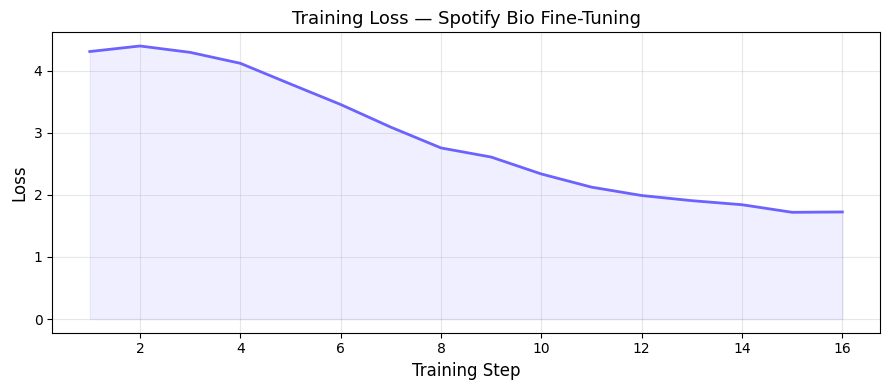

Start loss: 4.308   →   End loss: 1.724


In [ ]:
# ── DEMO MOMENT 3 ──────────────────────────────────────────────────────────
# Plot the loss curve. Walk students through what the shape tells you.
#
# Healthy curve: drops sharply early, flattens and levels off.
# Overfit curve: keeps dropping to near-zero (memorizing, not learning).
# Unhealthy curve: noisy / not converging (learning rate too high, or bad data).
#
# Ask: "Where on this curve would you have stopped training? Why?"
# ───────────────────────────────────────────────────────────────────────────

log_history = trainer.state.log_history
steps  = [entry['step'] for entry in log_history if 'loss' in entry]
losses = [entry['loss'] for entry in log_history if 'loss' in entry]

plt.figure(figsize=(9, 4))
plt.plot(steps, losses, color='#6C63FF', linewidth=2)
plt.fill_between(steps, losses, alpha=0.1, color='#6C63FF')
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss — Spotify Bio Fine-Tuning', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Start loss: {losses[0]:.3f}   →   End loss: {losses[-1]:.3f}')

---
## Part 4: Before / After Comparison

Same model. Same prompt format. Different weights.

**✍️ LIVE CODE — write the `compare()` function, then take student suggestions:**

In [ ]:
# ── INSTRUCTOR: Write this live. ────────────────────────────────────────────
#
# This is a short function — the payoff is running it, not writing it.
# Take 2–3 minutes to write it, then spend the rest of the demo taking
# artist suggestions from students.
#
# Ask before writing: "What do we need to compare? Same prompt, two models."
# Then write it together.
#
# After writing: ask for a student to suggest an artist NOT in the training
# data. Run it. Ask: "Did the style transfer? What's still off?"
# ────────────────────────────────────────────────────────────────────────────

def compare(artist: str, genre: str, descriptors: str):
    """Run the same bio prompt through the base and fine-tuned models."""
    prompt = bio_prompt(artist, genre, descriptors)

    print(f'Artist: {artist}')
    print('=' * 60)

    print('BASE MODEL:')
    with model.disable_adapter():
      print(generate(model, prompt))

    print('\nFINE-TUNED MODEL:')
    print(generate(model, prompt))
    print()


print('compare() defined. Ready for student suggestions.')

compare() defined. Ready for student suggestions.


In [ ]:
# ── DEMO MOMENT 4 ──────────────────────────────────────────────────────────
# Run the same three artists from the baseline. Show the shift.
# Ask: "What changed? What's still not right?"
# ───────────────────────────────────────────────────────────────────────────

compare('Frank Ocean',  'R&B / neo-soul', 'introspective lyrics, rare releases, emotional depth')
compare('Mitski',       'indie rock',     'longing, intensity, disappearing into another person')
compare('Tyler, the Creator', 'rap / neo-soul', 'chaos into genre, outgrowing yourself, visual art')

Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Artist: Frank Ocean
BASE MODEL:


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Frank Ocean's music is a slow-burning incantation, a midnight prayer for connection and understanding in a world that often seems too loud and too broken. His words are a delicate balance of vulnerability and introspection, plumbing the depths of the human experience with a quiet, unassuming authority. In his own private universe, Ocean reigns as a poet-king, weaving sonic tapestries that are at once deeply personal and universally relatable.

FINE-TUNED MODEL:


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Mitski's sound is a slow-motion collision of heartbreak and disintegration, as if she's been erasing herself from the world and leaving only echoes of her own longing in her wake. In her music, the ache of being lost in someone else's eyes is palpable, a crushing intensity that threatens to consume her. When she disappears into the depths of another person's soul, her songs become a haunting testament to the fragility of human connection.

FINE-TUNED MODEL:


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Mitski writes about what it's like to feel like you're disappearing into another person. Her music is for people who don't like their own.

Artist: Tyler, the Creator
BASE MODEL:


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tyler, the Creator is a sonic disruptor, conjuring a world where rap's raw energy meets the soulful decay of a bygone era. His sound is a manifestation of the chaos he's always cultivated, a restless synthesis of his own creative unease and the world's. In his music, you can hear the ghosts of his own genre-bending experiments, a visual artist's fevered imagination bleeding into every beat.

FINE-TUNED MODEL:
Tyler, the Creator is chaos into genre. He outgrew himself. He made visual art.



In [ ]:
# ── TRY IT — take artist suggestions from students ─────────────────────────
# Change the values below and re-run.
# Try artists that WEREN'T in the training data to test generalization.
# ───────────────────────────────────────────────────────────────────────────

compare(
    artist='Doechii',
    genre='rap / experimental',
    descriptors='unhinged energy, Tampa, hypnotic flow',
)

Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Artist: Doechii
BASE MODEL:


Both `max_new_tokens` (=150) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In the swampy haze of Tampa, Doechii conjures a sonic maelstrom that is equal parts unsettling and entrancing, her unhinged energy careening between abrasive rap and hypnotic beats like a rebellious fever dream. Like a femme-fatale mystic, she weaves a spell of sonic chaos, her voice a siren's wail that will leave you breathless and bewitched. When the lights go out and the city's rhythm takes over, Doechii is the soundtrack to the chaos.

FINE-TUNED MODEL:
Doechii rips.



---
## Discussion

**What fine-tuning changed:** The model learned a tone — evocative, short, sensory — from 65 examples. It no longer writes Wikipedia summaries for this task.

**What fine-tuning didn't change:** The model's underlying knowledge of artists, music, and language. Fine-tuning shaped *how* it responds, not *what* it knows.

**When would you use fine-tuning vs. a better prompt?**
- If a carefully engineered system prompt with good examples already gets you there → skip fine-tuning
- If the style is highly specific and consistent (like this one), or you're running thousands of requests and want to shrink the prompt → fine-tuning earns its cost
- If your real problem is lack of domain knowledge (e.g., a model that doesn't know your company's products) → fine-tuning won't help; RAG is the right tool

**What would make this better?**
- More examples (200–500 would improve consistency)
- More diverse genres in the training data
- Evaluation: systematically comparing base vs. fine-tuned outputs on a held-out set, not just vibing it

---

**A note on the project:** The demo today used a generative decoder model (Llama via Unsloth) for a text generation task. The project uses **DistilBERT** — an encoder-only model fine-tuned for classification. The architecture is different: DistilBERT reads a full sequence and outputs a class label, rather than generating tokens one at a time. But the underlying logic is the same — you're teaching the model a pattern it doesn't know from pretraining alone. Dataset quality, label precision, and honest evaluation matter just as much for a classifier as they do for a bio generator. The skills transfer directly.